<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/MLP_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)
print(y_train[0])
print(y_test[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
5
7


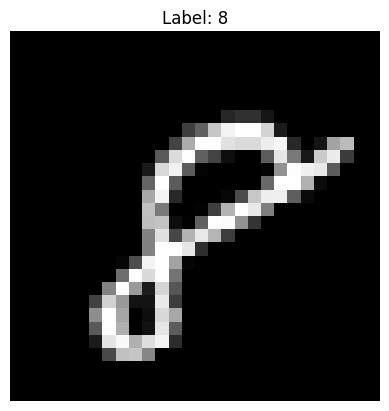

In [ ]:
plt.imshow(X_train[59999], cmap="gray")
plt.title(f"Label: {y_train[59999]}")
plt.axis("off")
plt.show()

In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
print(X_train.shape)

(60000, 784)


In [ ]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [ ]:
def one_hot(y, num_classes=10):
    result = np.zeros((y.shape[0], num_classes))
    result[np.arange(y.shape[0]), y] = 1
    return result

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)
print(Y_train.shape)
print(Y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
def relu(x):
    return np.maximum(0, x)
def relu_grad(x):
    return np.where(x > 0, 1.0, 0.0)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    #print(y_pred.shape)
    #print(y_true.shape)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

**Initialize the MLP**

In [ ]:
np.random.seed(42)

#he

W1 = np.random.randn(784, 128) * np.sqrt(2 / 784)

b1 = np.zeros((1, 128))

#print(W1.shape)

#print(b1.shape)

W2 = np.random.randn(128, 64) * np.sqrt(2 / 128)

b2 = np.zeros((1, 64))



W3 = np.random.randn(64, 10) * np.sqrt(2 / 64)

b3 = np.zeros((1, 10))

**Forward propagation**

In [ ]:
def forward(X):
    z1 = X @ W1 + b1
    #print(z1.shape)
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    y_pred = softmax(z3)

    cache = (X, z1, a1, z2, a2, z3, y_pred)

    return y_pred, cache

In [ ]:
def backward(y_true, cache):
    X, z1, a1, z2, a2, z3, y_pred = cache

    m = X.shape[0]

    # Output layer
    #grad of loss w .r.t weighted sum
    #like calculate for the average correction for the single image
    dz3 = (y_pred - y_true) / m

    dW3 = a2.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)

    # Hidden layer 2
    da2 = dz3 @ W3.T
    #local error
    dz2 = da2 * relu_grad(z2)

    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden layer 1
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_grad(z1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

In [ ]:
def get_accuracy(y_pred, y_true):
    predictions = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    accuracy = np.mean(predictions == true_labels) * 100
    return accuracy

**Stochastic Gradient Descent**

In [ ]:
epochs = 5
batch_size = 1
learning_rate = 0.01
loss_history = []
for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    # The computer looks at indices [2, 0, 1]
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(X_train) // batch_size
    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # Loss
        loss = cross_entropy(Y_batch, y_pred)
        total_loss += loss
        #print(np.mean(loss))
        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)

        dW1, db1, dW2, db2, dW3, db3 = gradients

        # Weight update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1


        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3
    # 4. Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)
    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {average_loss:.4f}, "
        f"Accuracy: {average_accuracy:.2f}%"
    )

Epoch 1/5, Loss: 0.0584, Accuracy: 98.14%
Epoch 2/5, Loss: 0.0517, Accuracy: 98.36%
Epoch 3/5, Loss: 0.0417, Accuracy: 98.67%
Epoch 4/5, Loss: 0.0363, Accuracy: 98.80%
Epoch 5/5, Loss: 0.0347, Accuracy: 98.84%


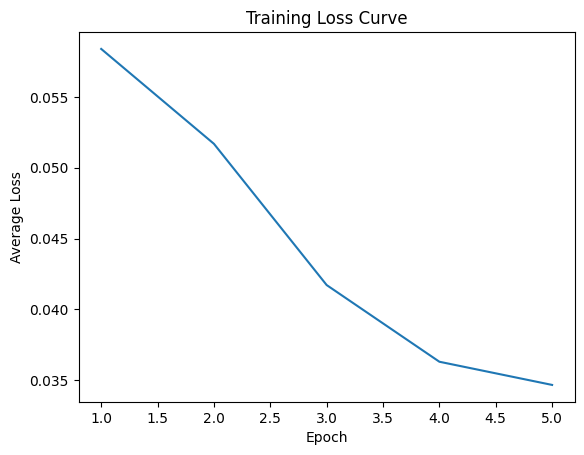

In [ ]:
epoch_numbers = list(range(1, epochs + 1))

plt.plot(epoch_numbers,loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.show()

**Mini-Batch SGD**

In [ ]:
epochs = 10
batch_size = 64
learning_rate = 0.01
loss_history = []
for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    # The computer looks at indices [2, 0, 1]
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(X_train) // batch_size
    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # Loss
        loss = cross_entropy(Y_batch, y_pred)
        total_loss += loss
        #print(np.mean(loss))
        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)

        dW1, db1, dW2, db2, dW3, db3 = gradients

        # Weight update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1


        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3
    # 4. Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)
    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {average_loss:.4f}, "
        f"Accuracy: {average_accuracy:.2f}%"
    )

Epoch 1/10, Loss: 0.7964, Accuracy: 78.62%
Epoch 2/10, Loss: 0.3604, Accuracy: 89.83%
Epoch 3/10, Loss: 0.2999, Accuracy: 91.57%
Epoch 4/10, Loss: 0.2645, Accuracy: 92.52%
Epoch 5/10, Loss: 0.2389, Accuracy: 93.34%
Epoch 6/10, Loss: 0.2183, Accuracy: 94.01%
Epoch 7/10, Loss: 0.2017, Accuracy: 94.46%
Epoch 8/10, Loss: 0.1876, Accuracy: 94.79%
Epoch 9/10, Loss: 0.1751, Accuracy: 95.16%
Epoch 10/10, Loss: 0.1644, Accuracy: 95.45%


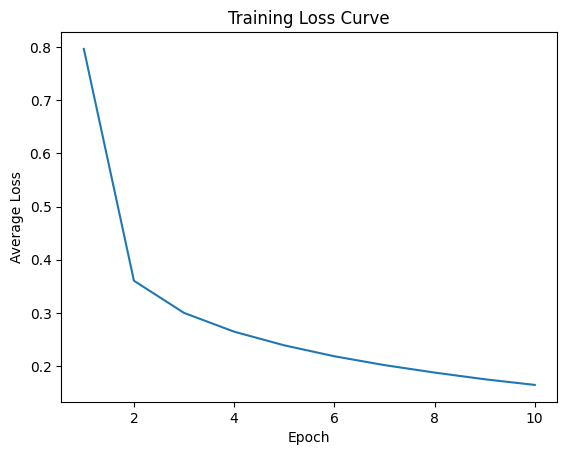

In [ ]:
epoch_numbers = list(range(1, epochs + 1))

plt.plot(epoch_numbers,loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.show()

**Testing**

In [ ]:
test_predictions, _ = forward(X_test)

test_acc = get_accuracy(test_predictions, Y_test)

print(f"Final Test Accuracy: {test_acc:.2f}%")

Final Test Accuracy: 95.29%


**Batch Gradient Descent**

In [ ]:
epochs = 3
#batch_size = 64  # Changed from 1 to 64 for stability and speed
learning_rate = 0.001
loss_history = []

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    #num_batches = len(X_train) // batch_size

    '''for start in range(0, len(X_train)):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]'''

        # Forward propagation
    y_pred, cache = forward(X_train_shuffled)

        # Loss
    loss = cross_entropy(Y_train_shuffled, y_pred)
    total_loss += loss

    accuracy = get_accuracy(y_pred, Y_train_shuffled)
    total_accuracy += accuracy

        # Backpropagation
    gradients = backward(Y_train_shuffled, cache)

        # Unpack all 10 gradients for the 5-layer architecture
    dW1, db1, dW2, db2, dW3, db3 = gradients

        # Weight update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3


    loss_history.append(total_loss)

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {total_loss:.4f}, "
        f"Accuracy: {total_accuracy:.2f}%"
    )

Epoch 1/3, Loss: 0.1743, Accuracy: 95.06%
Epoch 2/3, Loss: 0.1743, Accuracy: 95.06%
Epoch 3/3, Loss: 0.1742, Accuracy: 95.06%


**Model Performance on Validation**

In [ ]:
X_val = X_train[-10000:]
Y_val = Y_train[-10000:]

#Keep the rest (everything except the last 10,000) for the Training Set
X_train = X_train[:-10000]
Y_train = Y_train[:-10000]

**Mini Batch SGD**

In [ ]:
epochs = 10
batch_size = 64
learning_rate = 0.01
loss_history = []
val_loss_history = []
for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    # The computer looks at indices [2, 0, 1]
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(X_train) // batch_size
    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # Loss
        loss = cross_entropy(Y_batch, y_pred)
        total_loss += loss
        #print(np.mean(loss))
        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)

        dW1, db1, dW2, db2, dW3, db3 = gradients

        # Weight update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1


        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3
    # 4. Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)


    #Validation phase
    y_val_pred, _ = forward(X_val)
    val_loss = cross_entropy(Y_val, y_val_pred)
    val_accuracy = get_accuracy(y_val_pred, Y_val)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {average_loss:.4f}, Train Acc: {average_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%"
    )

Epoch 1/10 | Train Loss: 0.8785, Train Acc: 76.62% | Val Loss: 0.4140, Val Acc: 88.98%
Epoch 2/10 | Train Loss: 0.3888, Train Acc: 89.11% | Val Loss: 0.3176, Val Acc: 91.13%
Epoch 3/10 | Train Loss: 0.3214, Train Acc: 90.86% | Val Loss: 0.2793, Val Acc: 92.06%
Epoch 4/10 | Train Loss: 0.2849, Train Acc: 91.99% | Val Loss: 0.2557, Val Acc: 92.72%
Epoch 5/10 | Train Loss: 0.2590, Train Acc: 92.76% | Val Loss: 0.2418, Val Acc: 93.02%
Epoch 6/10 | Train Loss: 0.2377, Train Acc: 93.43% | Val Loss: 0.2161, Val Acc: 93.70%
Epoch 7/10 | Train Loss: 0.2202, Train Acc: 93.90% | Val Loss: 0.2038, Val Acc: 94.33%
Epoch 8/10 | Train Loss: 0.2061, Train Acc: 94.30% | Val Loss: 0.1922, Val Acc: 94.62%
Epoch 9/10 | Train Loss: 0.1927, Train Acc: 94.65% | Val Loss: 0.1798, Val Acc: 95.03%
Epoch 10/10 | Train Loss: 0.1817, Train Acc: 94.97% | Val Loss: 0.1733, Val Acc: 95.20%


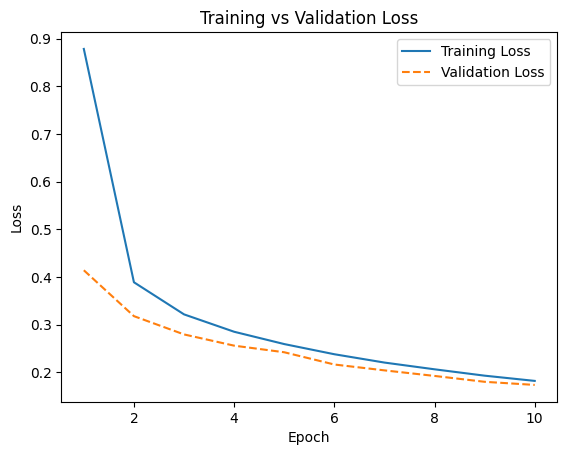

In [ ]:

epoch_numbers = list(range(1, epochs + 1))

plt.plot(epoch_numbers, loss_history, label="Training Loss")

plt.plot(epoch_numbers, val_loss_history, label="Validation Loss", linestyle="--")

# Add labels and title
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**Adam optimizer**

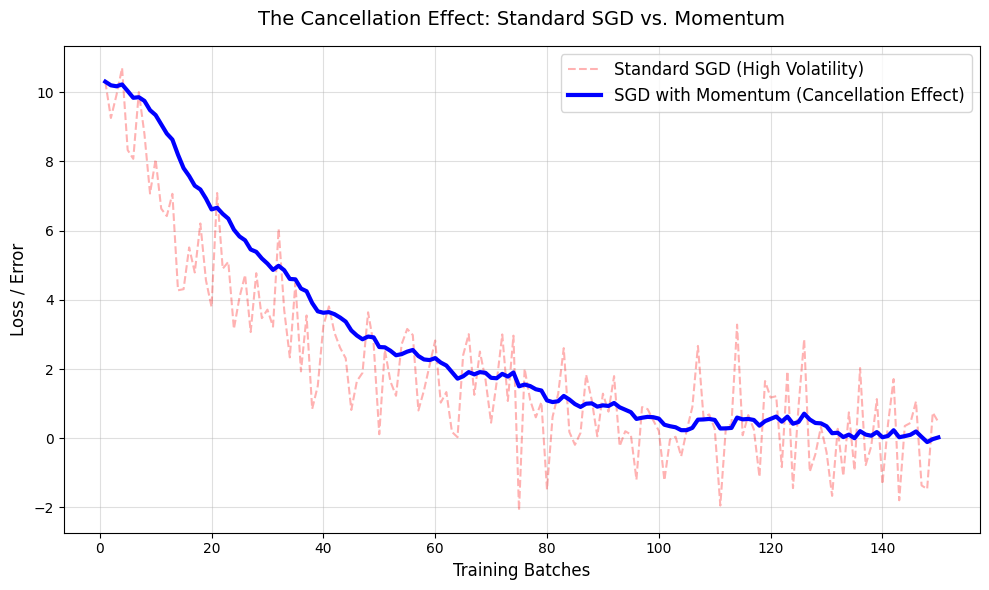

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
batches = np.arange(1, 151)

base_descent = 10 * np.exp(-0.03 * batches)
noise = np.random.normal(0, 1.2, size=len(batches))
sgd_loss = base_descent + noise

# 2. Apply Momentum logic (beta = 0.9) to simulate the cancellation effect
beta = 0.9
momentum_loss = np.zeros_like(sgd_loss)
momentum_loss[0] = sgd_loss[0]

for t in range(1, len(batches)):
    momentum_loss[t] = beta * momentum_loss[t-1] + (1 - beta) * sgd_loss[t]

# 3. Plotting the comparison
plt.figure(figsize=(10, 6))

# Plot the raw, noisy SGD
plt.plot(batches, sgd_loss, label='Standard SGD (High Volatility)',
         alpha=0.3, color='red', linestyle='--')

# Plot the smoothed Momentum line
plt.plot(batches, momentum_loss, label='SGD with Momentum (Cancellation Effect)',
         linewidth=3, color='blue')

plt.title('The Cancellation Effect: Standard SGD vs. Momentum', fontsize=14, pad=15)
plt.xlabel('Training Batches', fontsize=12)
plt.ylabel('Loss / Error', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

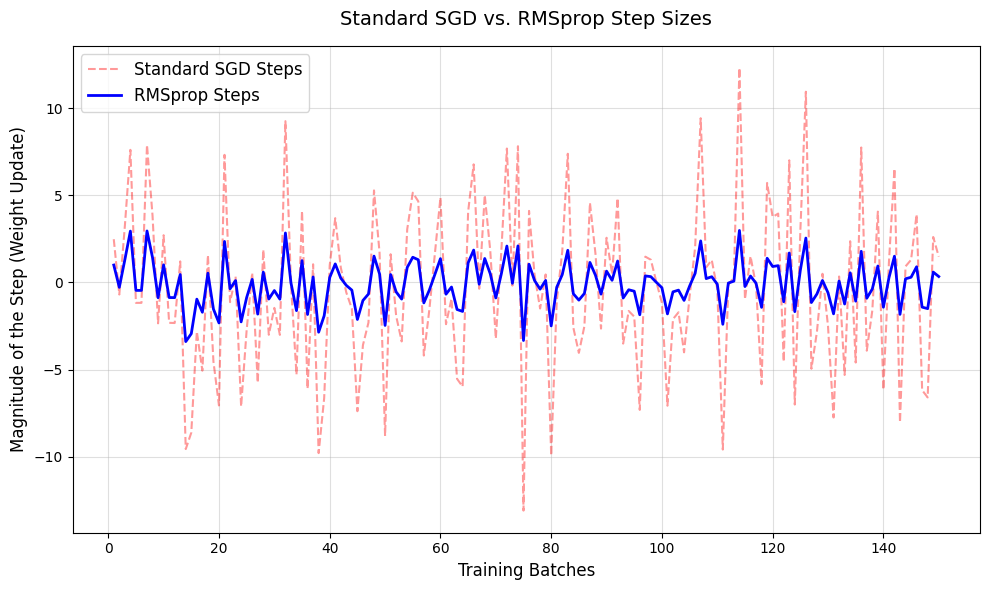

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
batches = np.arange(1, 151)


raw_gradients = np.random.normal(0, 5.0, size=len(batches))

beta2 = 0.99
epsilon = 1e-8
v_t = np.zeros_like(raw_gradients)
rmsprop_steps = np.zeros_like(raw_gradients)

v_t[0] = raw_gradients[0]**2
rmsprop_steps[0] = raw_gradients[0] / (np.sqrt(v_t[0]) + epsilon)

for t in range(1, len(batches)):
    # Track the squared volatility
    v_t[t] = beta2 * v_t[t-1] + (1 - beta2) * (raw_gradients[t] ** 2)


    rmsprop_steps[t] = raw_gradients[t] / (np.sqrt(v_t[t]) + epsilon)

# 4. Plotting the comparison
plt.figure(figsize=(10, 6))

# Plot the raw, dangerous SGD steps
plt.plot(batches, raw_gradients, label='Standard SGD Steps',
         alpha=0.4, color='red', linestyle='--')

# Plot the RMSprop controlled steps
plt.plot(batches, rmsprop_steps, label='RMSprop Steps',
         linewidth=2, color='blue')

plt.title('Standard SGD vs. RMSprop Step Sizes', fontsize=14, pad=15)
plt.xlabel('Training Batches', fontsize=12)
plt.ylabel('Magnitude of the Step (Weight Update)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:

beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
t = 0


vdW1, sdW1 = np.zeros_like(W1), np.zeros_like(W1)
vdb1, sdb1 = np.zeros_like(b1), np.zeros_like(b1)

vdW2, sdW2 = np.zeros_like(W2), np.zeros_like(W2)
vdb2, sdb2 = np.zeros_like(b2), np.zeros_like(b2)

vdW3, sdW3 = np.zeros_like(W3), np.zeros_like(W3)
vdb3, sdb3 = np.zeros_like(b3), np.zeros_like(b3)

# ==========================================
# PHASE 2: TRAINING LOOP
# ==========================================
epochs = 10
batch_size = 64
learning_rate = 0.001
loss_history = []
val_loss_history = []

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(range(0, len(X_train), batch_size))
    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # Loss & Accuracy
        loss = cross_entropy(Y_batch, y_pred)
        total_loss += loss
        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)
        dW1, db1, dW2, db2, dW3, db3 = gradients

        # ==========================================
        # PHASE 3: ADAM WEIGHT UPDATES
        # ==========================================
        # Increment time step once per batch
        t += 1

        # Layer 1 Adam Update
        vdW1 = beta1 * vdW1 + (1 - beta1) * dW1
        vdb1 = beta1 * vdb1 + (1 - beta1) * db1
        sdW1 = beta2 * sdW1 + (1 - beta2) * (dW1 ** 2)
        sdb1 = beta2 * sdb1 + (1 - beta2) * (db1 ** 2)

        vdW1_corr = vdW1 / (1 - beta1 ** t)
        vdb1_corr = vdb1 / (1 - beta1 ** t)
        sdW1_corr = sdW1 / (1 - beta2 ** t)
        sdb1_corr = sdb1 / (1 - beta2 ** t)

        W1 -= learning_rate * (vdW1_corr / (np.sqrt(sdW1_corr) + epsilon))
        b1 -= learning_rate * (vdb1_corr / (np.sqrt(sdb1_corr) + epsilon))

        # Layer 2 Adam Update
        vdW2 = beta1 * vdW2 + (1 - beta1) * dW2
        vdb2 = beta1 * vdb2 + (1 - beta1) * db2
        sdW2 = beta2 * sdW2 + (1 - beta2) * (dW2 ** 2)
        sdb2 = beta2 * sdb2 + (1 - beta2) * (db2 ** 2)

        vdW2_corr = vdW2 / (1 - beta1 ** t)
        vdb2_corr = vdb2 / (1 - beta1 ** t)
        sdW2_corr = sdW2 / (1 - beta2 ** t)
        sdb2_corr = sdb2 / (1 - beta2 ** t)

        W2 -= learning_rate * (vdW2_corr / (np.sqrt(sdW2_corr) + epsilon))
        b2 -= learning_rate * (vdb2_corr / (np.sqrt(sdb2_corr) + epsilon))

        # Layer 3 Adam Update
        vdW3 = beta1 * vdW3 + (1 - beta1) * dW3
        vdb3 = beta1 * vdb3 + (1 - beta1) * db3
        sdW3 = beta2 * sdW3 + (1 - beta2) * (dW3 ** 2)
        sdb3 = beta2 * sdb3 + (1 - beta2) * (db3 ** 2)

        vdW3_corr = vdW3 / (1 - beta1 ** t)
        vdb3_corr = vdb3 / (1 - beta1 ** t)
        sdW3_corr = sdW3 / (1 - beta2 ** t)
        sdb3_corr = sdb3 / (1 - beta2 ** t)

        W3 -= learning_rate * (vdW3_corr / (np.sqrt(sdW3_corr) + epsilon))
        b3 -= learning_rate * (vdb3_corr / (np.sqrt(sdb3_corr) + epsilon))

    # Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)

    # Validation phase
    y_val_pred, _ = forward(X_val)
    val_loss = cross_entropy(Y_val, y_val_pred)
    val_accuracy = get_accuracy(y_val_pred, Y_val)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {average_loss:.4f}, Train Acc: {average_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%"
    )

Epoch 1/10 | Train Loss: 0.1167, Train Acc: 96.56% | Val Loss: 0.0883, Val Acc: 97.38%
Epoch 2/10 | Train Loss: 0.0813, Train Acc: 97.57% | Val Loss: 0.1116, Val Acc: 96.78%
Epoch 3/10 | Train Loss: 0.0599, Train Acc: 98.11% | Val Loss: 0.0861, Val Acc: 97.45%
Epoch 4/10 | Train Loss: 0.0473, Train Acc: 98.50% | Val Loss: 0.0840, Val Acc: 97.66%
Epoch 5/10 | Train Loss: 0.0370, Train Acc: 98.90% | Val Loss: 0.0794, Val Acc: 97.84%
Epoch 6/10 | Train Loss: 0.0291, Train Acc: 99.08% | Val Loss: 0.0838, Val Acc: 97.80%
Epoch 7/10 | Train Loss: 0.0245, Train Acc: 99.23% | Val Loss: 0.0933, Val Acc: 97.61%
Epoch 8/10 | Train Loss: 0.0200, Train Acc: 99.39% | Val Loss: 0.0866, Val Acc: 97.81%
Epoch 9/10 | Train Loss: 0.0184, Train Acc: 99.38% | Val Loss: 0.1152, Val Acc: 97.32%
Epoch 10/10 | Train Loss: 0.0177, Train Acc: 99.40% | Val Loss: 0.0948, Val Acc: 97.69%


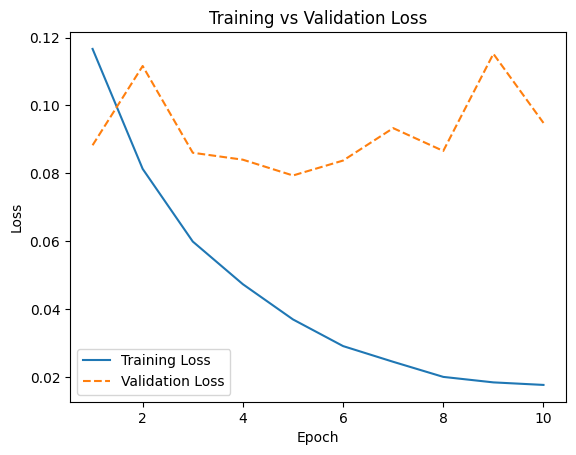

In [ ]:

epoch_numbers = list(range(1, epochs + 1))

plt.plot(epoch_numbers, loss_history, label="Training Loss")

plt.plot(epoch_numbers, val_loss_history, label="Validation Loss", linestyle="--")

# Add labels and title
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:

epochs = 10
batch_size = 64
learning_rate = 0.001
lambda_reg = 0.01


beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
t = 0


vdW1, sdW1 = np.zeros_like(W1), np.zeros_like(W1)
vdb1, sdb1 = np.zeros_like(b1), np.zeros_like(b1)

vdW2, sdW2 = np.zeros_like(W2), np.zeros_like(W2)
vdb2, sdb2 = np.zeros_like(b2), np.zeros_like(b2)

vdW3, sdW3 = np.zeros_like(W3), np.zeros_like(W3)
vdb3, sdb3 = np.zeros_like(b3), np.zeros_like(b3)

loss_history = []
val_loss_history = []


for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(range(0, len(X_train), batch_size))

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # 1. Forward propagation
        y_pred, cache = forward(X_batch)


        m = X_batch.shape[0]
        L2_penalty = (lambda_reg / (2 * m)) * (np.sum(np.square(W1)) +
                                               np.sum(np.square(W2)) +
                                               np.sum(np.square(W3)))

        loss = cross_entropy(Y_batch, y_pred) + L2_penalty
        total_loss += loss

        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # 3. Backpropagation
        gradients = backward(Y_batch, cache)
        dW1, db1, dW2, db2, dW3, db3 = gradients

        # 4. Apply L2 Regularization to Gradients
        dW1 += (lambda_reg / m) * W1
        dW2 += (lambda_reg / m) * W2
        dW3 += (lambda_reg / m) * W3


        t += 1

        # Layer 1 Adam Update
        vdW1 = beta1 * vdW1 + (1 - beta1) * dW1
        vdb1 = beta1 * vdb1 + (1 - beta1) * db1
        sdW1 = beta2 * sdW1 + (1 - beta2) * (dW1 ** 2)
        sdb1 = beta2 * sdb1 + (1 - beta2) * (db1 ** 2)

        vdW1_corr = vdW1 / (1 - beta1 ** t)
        vdb1_corr = vdb1 / (1 - beta1 ** t)
        sdW1_corr = sdW1 / (1 - beta2 ** t)
        sdb1_corr = sdb1 / (1 - beta2 ** t)

        W1 -= learning_rate * (vdW1_corr / (np.sqrt(sdW1_corr) + epsilon))
        b1 -= learning_rate * (vdb1_corr / (np.sqrt(sdb1_corr) + epsilon))

        # Layer 2 Adam Update
        vdW2 = beta1 * vdW2 + (1 - beta1) * dW2
        vdb2 = beta1 * vdb2 + (1 - beta1) * db2
        sdW2 = beta2 * sdW2 + (1 - beta2) * (dW2 ** 2)
        sdb2 = beta2 * sdb2 + (1 - beta2) * (db2 ** 2)

        vdW2_corr = vdW2 / (1 - beta1 ** t)
        vdb2_corr = vdb2 / (1 - beta1 ** t)
        sdW2_corr = sdW2 / (1 - beta2 ** t)
        sdb2_corr = sdb2 / (1 - beta2 ** t)

        W2 -= learning_rate * (vdW2_corr / (np.sqrt(sdW2_corr) + epsilon))
        b2 -= learning_rate * (vdb2_corr / (np.sqrt(sdb2_corr) + epsilon))

        # Layer 3 Adam Update
        vdW3 = beta1 * vdW3 + (1 - beta1) * dW3
        vdb3 = beta1 * vdb3 + (1 - beta1) * db3
        sdW3 = beta2 * sdW3 + (1 - beta2) * (dW3 ** 2)
        sdb3 = beta2 * sdb3 + (1 - beta2) * (db3 ** 2)

        vdW3_corr = vdW3 / (1 - beta1 ** t)
        vdb3_corr = vdb3 / (1 - beta1 ** t)
        sdW3_corr = sdW3 / (1 - beta2 ** t)
        sdb3_corr = sdb3 / (1 - beta2 ** t)

        W3 -= learning_rate * (vdW3_corr / (np.sqrt(sdW3_corr) + epsilon))
        b3 -= learning_rate * (vdb3_corr / (np.sqrt(sdb3_corr) + epsilon))

    # Calculate epoch averages
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)

    # ==========================================
    # PHASE 4: VALIDATION
    # ==========================================
    y_val_pred, _ = forward(X_val)

    # Calculate L2 Penalty strictly for the full validation dataset size
    m_val = X_val.shape[0]
    val_L2_penalty = (lambda_reg / (2 * m_val)) * (np.sum(np.square(W1)) +
                                                   np.sum(np.square(W2)) +
                                                   np.sum(np.square(W3)))

    val_loss = cross_entropy(Y_val, y_val_pred) + val_L2_penalty
    val_accuracy = get_accuracy(y_val_pred, Y_val)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {average_loss:.4f}, Train Acc: {average_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%"
    )

Epoch 1/10 | Train Loss: 0.0983, Train Acc: 99.58% | Val Loss: 0.1019, Val Acc: 97.71%
Epoch 2/10 | Train Loss: 0.0814, Train Acc: 99.85% | Val Loss: 0.0889, Val Acc: 97.97%
Epoch 3/10 | Train Loss: 0.0760, Train Acc: 99.73% | Val Loss: 0.0865, Val Acc: 97.80%
Epoch 4/10 | Train Loss: 0.0745, Train Acc: 99.61% | Val Loss: 0.0840, Val Acc: 97.89%
Epoch 5/10 | Train Loss: 0.0662, Train Acc: 99.77% | Val Loss: 0.0821, Val Acc: 98.02%
Epoch 6/10 | Train Loss: 0.0655, Train Acc: 99.63% | Val Loss: 0.0820, Val Acc: 97.97%
Epoch 7/10 | Train Loss: 0.0628, Train Acc: 99.63% | Val Loss: 0.0821, Val Acc: 97.81%
Epoch 8/10 | Train Loss: 0.0616, Train Acc: 99.61% | Val Loss: 0.0789, Val Acc: 97.79%
Epoch 9/10 | Train Loss: 0.0591, Train Acc: 99.64% | Val Loss: 0.0747, Val Acc: 98.11%
Epoch 10/10 | Train Loss: 0.0583, Train Acc: 99.65% | Val Loss: 0.0768, Val Acc: 98.03%


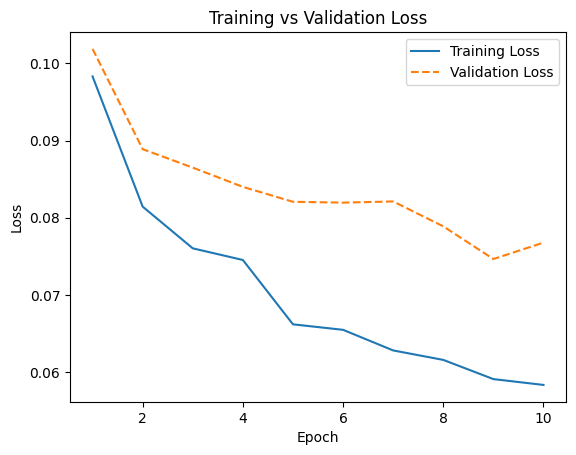

In [ ]:

epoch_numbers = list(range(1, epochs + 1))

plt.plot(epoch_numbers, loss_history, label="Training Loss")

plt.plot(epoch_numbers, val_loss_history, label="Validation Loss", linestyle="--")

# Add labels and title
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**Early Stopping**

In [ ]:
epochs = 50
batch_size = 64
learning_rate = 0.01

patience = 3
strikes = 0
best_val_loss = float('inf')


loss_history = []
val_loss_history = []

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    # The computer looks at indices [2, 0, 1]
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(X_train) // batch_size
    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # Loss
        loss = cross_entropy(Y_batch, y_pred)
        total_loss += loss
        #print(np.mean(loss))
        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)

        dW1, db1, dW2, db2, dW3, db3 = gradients

        # Weight update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1


        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3
    # 4. Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)


    #Validation phase
    y_val_pred, _ = forward(X_val)
    val_loss = cross_entropy(Y_val, y_val_pred)
    val_accuracy = get_accuracy(y_val_pred, Y_val)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {average_loss:.4f}, Train Acc: {average_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        strikes = 0

    else:
        # Step B: No improvement. Add a strike.
        strikes += 1
        print(f"  -> Warning: Strike {strikes}/{patience}. Val loss did not improve.")

        # Step C: Check if we have hit the maximum allowed strikes
        if strikes >= patience:
            print(f"\nEarly stopping triggered! Training killed at Epoch {epoch + 1} to prevent overfitting.")
            break

Epoch 1/50 | Train Loss: 0.3719, Train Acc: 89.50% | Val Loss: 0.3110, Val Acc: 91.29%
Epoch 2/50 | Train Loss: 0.3143, Train Acc: 91.14% | Val Loss: 0.2715, Val Acc: 92.24%
Epoch 3/50 | Train Loss: 0.2804, Train Acc: 92.10% | Val Loss: 0.2471, Val Acc: 92.95%
Epoch 4/50 | Train Loss: 0.2552, Train Acc: 92.98% | Val Loss: 0.2271, Val Acc: 93.41%
Epoch 5/50 | Train Loss: 0.2352, Train Acc: 93.46% | Val Loss: 0.2127, Val Acc: 93.88%
Epoch 6/50 | Train Loss: 0.2185, Train Acc: 93.99% | Val Loss: 0.2011, Val Acc: 94.42%
Epoch 7/50 | Train Loss: 0.2042, Train Acc: 94.39% | Val Loss: 0.1883, Val Acc: 94.72%
Epoch 8/50 | Train Loss: 0.1913, Train Acc: 94.66% | Val Loss: 0.1807, Val Acc: 95.06%
Epoch 9/50 | Train Loss: 0.1808, Train Acc: 95.03% | Val Loss: 0.1731, Val Acc: 95.20%
Epoch 10/50 | Train Loss: 0.1707, Train Acc: 95.29% | Val Loss: 0.1639, Val Acc: 95.56%
Epoch 11/50 | Train Loss: 0.1617, Train Acc: 95.61% | Val Loss: 0.1582, Val Acc: 95.67%
Epoch 12/50 | Train Loss: 0.1538, Train A

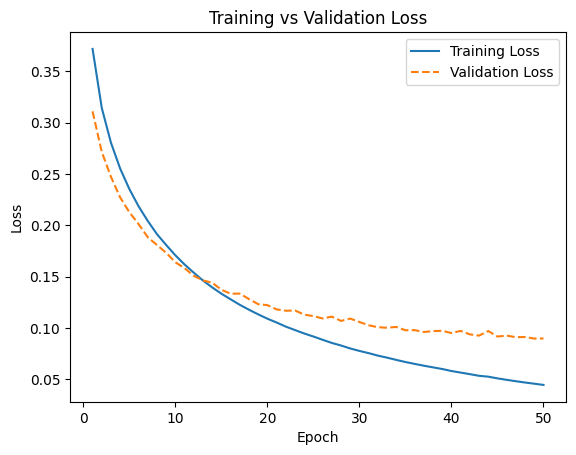

In [ ]:

epoch_numbers = list(range(1, epochs + 1))

plt.plot(epoch_numbers, loss_history, label="Training Loss")

plt.plot(epoch_numbers, val_loss_history, label="Validation Loss", linestyle="--")

# Add labels and title
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**L2 Regularization** Ridge


In [ ]:
epochs = 50
batch_size = 64
learning_rate = 0.01

#  Set the regularization penalty strength (lambda)
lambda_reg = 0.1

patience = 3
strikes = 0
best_val_loss = float('inf')

loss_history = []
val_loss_history = []

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(X_train) // batch_size

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # NEW STEP 2: Calculate the L2 Penalty and add it to the loss
        # Formula: (lambda / 2m) * sum(W^2)
        m = batch_size
        L2_penalty = (lambda_reg / (2 * m)) * (np.sum(np.square(W1)) + np.sum(np.square(W2)) + np.sum(np.square(W3)))

        # Add the penalty to the standard cross-entropy loss
        loss = cross_entropy(Y_batch, y_pred) + L2_penalty
        total_loss += loss

        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)
        dW1, db1, dW2, db2, dW3, db3 = gradients

        # NEW STEP 3: Add the regularization derivative to the weight gradients
        # Formula: dW = dW + (lambda / m) * W
        dW1 += (lambda_reg / m) * W1
        dW2 += (lambda_reg / m) * W2
        dW3 += (lambda_reg / m) * W3

        # Weight update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    # Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)

    # Validation phase
    y_val_pred, _ = forward(X_val)

    m_val = len(X_val)
    val_L2_penalty = (lambda_reg / (2 * m_val)) * (np.sum(np.square(W1)) + np.sum(np.square(W2)) + np.sum(np.square(W3)))

    val_loss = cross_entropy(Y_val, y_val_pred) + val_L2_penalty
    val_accuracy = get_accuracy(y_val_pred, Y_val)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {average_loss:.4f}, Train Acc: {average_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%"
    )

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        strikes = 0
    else:
        strikes += 1
        print(f"  -> Warning: Strike {strikes}/{patience}. Val loss did not improve.")
        if strikes >= patience:
            print(f"\nEarly stopping triggered! Training killed at Epoch {epoch + 1} to prevent overfitting.")
            break

Epoch 1/50 | Train Loss: 0.6965, Train Acc: 89.44% | Val Loss: 0.3177, Val Acc: 91.25%
Epoch 2/50 | Train Loss: 0.6369, Train Acc: 91.06% | Val Loss: 0.2794, Val Acc: 92.15%
Epoch 3/50 | Train Loss: 0.6005, Train Acc: 91.97% | Val Loss: 0.2559, Val Acc: 92.77%
Epoch 4/50 | Train Loss: 0.5725, Train Acc: 92.77% | Val Loss: 0.2367, Val Acc: 93.23%
Epoch 5/50 | Train Loss: 0.5498, Train Acc: 93.26% | Val Loss: 0.2240, Val Acc: 93.70%
Epoch 6/50 | Train Loss: 0.5302, Train Acc: 93.74% | Val Loss: 0.2125, Val Acc: 94.10%
Epoch 7/50 | Train Loss: 0.5129, Train Acc: 94.15% | Val Loss: 0.2008, Val Acc: 94.43%
Epoch 8/50 | Train Loss: 0.4972, Train Acc: 94.43% | Val Loss: 0.1938, Val Acc: 94.87%
Epoch 9/50 | Train Loss: 0.4837, Train Acc: 94.71% | Val Loss: 0.1862, Val Acc: 94.99%
Epoch 10/50 | Train Loss: 0.4706, Train Acc: 94.96% | Val Loss: 0.1777, Val Acc: 95.18%
Epoch 11/50 | Train Loss: 0.4587, Train Acc: 95.24% | Val Loss: 0.1722, Val Acc: 95.34%
Epoch 12/50 | Train Loss: 0.4478, Train A

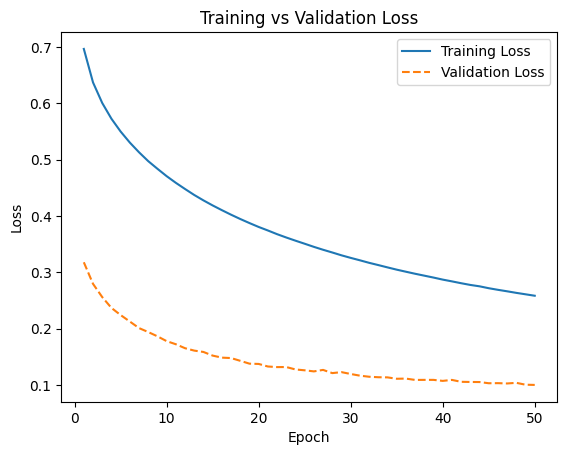

In [ ]:

epoch_numbers = list(range(1, epochs + 1))

plt.plot(epoch_numbers, loss_history, label="Training Loss")

plt.plot(epoch_numbers, val_loss_history, label="Validation Loss", linestyle="--")

# Add labels and title
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**L1 regualarization** Lasso


In [ ]:
epochs = 50
batch_size = 64
learning_rate = 0.01

# Set the regularization penalty strength (lambda)
lambda_reg = 0.1

patience = 3
strikes = 0
best_val_loss = float('inf')

loss_history = []
val_loss_history = []

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0
    total_accuracy = 0
    num_batches = len(X_train) // batch_size

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # ==========================================
        # CHANGED 1: Calculate the L1 Penalty (Absolute Value)
        # Formula: (lambda / m) * sum(|W|)
        # ==========================================
        m = batch_size
        L1_penalty = (lambda_reg / m) * (np.sum(np.abs(W1)) + np.sum(np.abs(W2)) + np.sum(np.abs(W3)))

        # Add the penalty to the standard cross-entropy loss
        loss = cross_entropy(Y_batch, y_pred) + L1_penalty
        total_loss += loss

        batch_accuracy = get_accuracy(y_pred, Y_batch)
        total_accuracy += batch_accuracy

        # Backpropagation
        gradients = backward(Y_batch, cache)
        dW1, db1, dW2, db2, dW3, db3 = gradients

        # ==========================================
        # CHANGED 2: Add the L1 derivative to the weight gradients (Sign)
        # Formula: dW = dW + (lambda / m) * sign(W)
        # ==========================================
        dW1 += (lambda_reg / m) * np.sign(W1)
        dW2 += (lambda_reg / m) * np.sign(W2)
        dW3 += (lambda_reg / m) * np.sign(W3)

        # Weight update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    # Calculate averages using num_batches
    average_loss = total_loss / num_batches
    average_accuracy = total_accuracy / num_batches
    loss_history.append(average_loss)

    # Validation phase
    y_val_pred, _ = forward(X_val)

    # ==========================================
    # CHANGED 3: Calculate L1 penalty for validation
    # ==========================================
    m_val = len(X_val)
    val_L1_penalty = (lambda_reg / m_val) * (np.sum(np.abs(W1)) + np.sum(np.abs(W2)) + np.sum(np.abs(W3)))

    val_loss = cross_entropy(Y_val, y_val_pred) + val_L1_penalty
    val_accuracy = get_accuracy(y_val_pred, Y_val)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {average_loss:.4f}, Train Acc: {average_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%"
    )

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        strikes = 0
    else:
        strikes += 1
        print(f"  -> Warning: Strike {strikes}/{patience}. Val loss did not improve.")
        if strikes >= patience:
            print(f"\nEarly stopping triggered! Training killed at Epoch {epoch + 1} to prevent overfitting.")
            break

Epoch 1/50 | Train Loss: 0.8629, Train Acc: 93.83% | Val Loss: 0.2415, Val Acc: 94.44%
Epoch 2/50 | Train Loss: 0.8448, Train Acc: 93.88% | Val Loss: 0.2389, Val Acc: 94.59%
Epoch 3/50 | Train Loss: 0.8287, Train Acc: 93.94% | Val Loss: 0.2379, Val Acc: 94.51%
Epoch 4/50 | Train Loss: 0.8136, Train Acc: 93.98% | Val Loss: 0.2362, Val Acc: 94.47%
Epoch 5/50 | Train Loss: 0.8000, Train Acc: 93.97% | Val Loss: 0.2338, Val Acc: 94.58%
Epoch 6/50 | Train Loss: 0.7869, Train Acc: 93.94% | Val Loss: 0.2328, Val Acc: 94.41%
Epoch 7/50 | Train Loss: 0.7750, Train Acc: 94.02% | Val Loss: 0.2313, Val Acc: 94.34%
Epoch 8/50 | Train Loss: 0.7633, Train Acc: 94.05% | Val Loss: 0.2346, Val Acc: 94.26%
  -> Warning: Strike 1/3. Val loss did not improve.
Epoch 9/50 | Train Loss: 0.7527, Train Acc: 94.10% | Val Loss: 0.2299, Val Acc: 94.55%
Epoch 10/50 | Train Loss: 0.7439, Train Acc: 94.10% | Val Loss: 0.2320, Val Acc: 94.49%
  -> Warning: Strike 1/3. Val loss did not improve.
Epoch 11/50 | Train Loss:

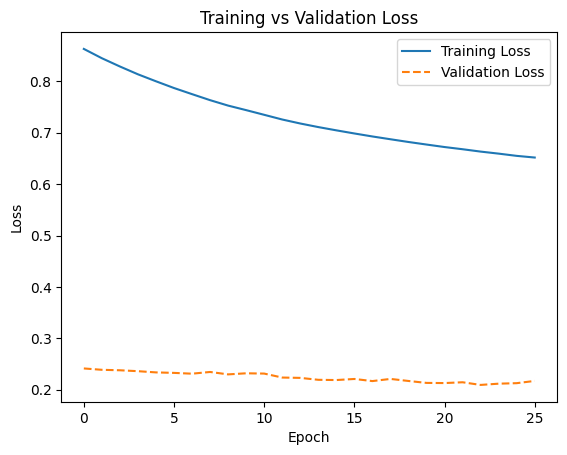

In [ ]:

#epoch_numbers = list(range(1, epochs + 1))

plt.plot(loss_history, label="Training Loss")

plt.plot( val_loss_history, label="Validation Loss", linestyle="--")

# Add labels and title
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()